# New York City Routing with A* Search

In [1]:
# If necessary, run this once and restart the kernel:
# %pip install -U osmnx networkx folium shapely matplotlib

from pathlib import Path
from time import perf_counter
import math
import tracemalloc

import networkx as nx
import osmnx as ox

ox.settings.use_cache = True
ox.settings.cache_folder = "osmnx_cache"
ox.settings.requests_timeout = 180


## Download or load the correctly sized street network


In [2]:
# Coordinates are specified as (latitude, longitude).
origin_point = (40.7484, -73.9857)       # Empire State Building
destination_point = (40.7826, -73.9656)  # Central Park


def haversine_m(lat1, lon1, lat2, lon2):
    """Return the great-circle distance between two coordinates in metres."""
    radius = 6_371_009.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (
        math.sin(dphi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * radius * math.asin(math.sqrt(a))


# A midpoint query with a 1.2 km margin covers both POIs without downloading
# an unnecessarily large circular network around Times Square.
center = (
    (origin_point[0] + destination_point[0]) / 2,
    (origin_point[1] + destination_point[1]) / 2,
)
direct_distance = haversine_m(*origin_point, *destination_point)
graph_radius = direct_distance / 2 + 1_200
graph_file = Path("nyc_empire_central_park_drive.graphml")

if graph_file.exists():
    G = ox.io.load_graphml(graph_file)
    print(f"Loaded cached graph: {graph_file}")
else:
    G = ox.graph.graph_from_point(
        center,
        dist=graph_radius,
        network_type="drive",
        simplify=True,
    )
    ox.io.save_graphml(G, graph_file)
    print(f"Downloaded and cached graph: {graph_file}")

# Find both nearest nodes in one vectorized call.
origin_id, destination_id = ox.distance.nearest_nodes(
    G,
    X=[origin_point[1], destination_point[1]],
    Y=[origin_point[0], destination_point[0]],
)

print(f"Straight-line POI distance: {direct_distance:,.1f} m")
print(f"Graph radius: {graph_radius:,.1f} m")
print(f"Graph: {len(G.nodes):,} nodes and {len(G.edges):,} edges")
print(f"Origin node: {origin_id}; destination node: {destination_id}")


Loaded cached graph: nyc_empire_central_park_drive.graphml
Straight-line POI distance: 4,162.6 m
Graph radius: 3,281.3 m
Graph: 2,170 nodes and 4,549 edges
Origin node: 42446701; destination node: 42433927


## Run the optimized A* search


In [3]:
def straight_line_heuristic(node_a, node_b):
    """Admissible distance heuristic for A* in metres."""
    a = G.nodes[node_a]
    b = G.nodes[node_b]
    return haversine_m(a["y"], a["x"], b["y"], b["x"])


def minimum_edge_length(G, u, v):
    """Return the shortest parallel edge between two route nodes."""
    return min(
        float(attributes.get("length", 1.0))
        for attributes in G.get_edge_data(u, v).values()
    )


def route_cost(G, route):
    """Return a route's network length in metres."""
    return sum(
        minimum_edge_length(G, u, v)
        for u, v in zip(route[:-1], route[1:])
    )


tracemalloc.start()
start = perf_counter()
route = nx.astar_path(
    G,
    origin_id,
    destination_id,
    heuristic=straight_line_heuristic,
    weight="length",
)
elapsed = perf_counter() - start
_, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

astar_cost = route_cost(G, route)

print(f"A* route cost: {astar_cost:,.1f} m")
print(f"Process time: {elapsed:.4f} s")
print(f"Peak traced memory: {peak_memory:,} bytes")
print(f"Nodes in route: {len(route):,}")


A* route cost: 4,809.4 m
Process time: 0.0064 s
Peak traced memory: 54,526 bytes
Nodes in route: 58


## Verify optimality against Dijkstra's algorithm


In [4]:
# This verification is optional. Both searches minimize the OSM 'length' attribute.
dijkstra_cost = nx.shortest_path_length(
    G,
    origin_id,
    destination_id,
    weight="length",
    method="dijkstra",
)

print(f"Dijkstra cost: {dijkstra_cost:,.1f} m")
print(f"Difference: {astar_cost - dijkstra_cost:.6f} m")
assert math.isclose(astar_cost, dijkstra_cost, rel_tol=1e-9, abs_tol=1e-6)


Dijkstra cost: 4,809.4 m
Difference: 0.000000 m


## Visualize the route on the street network


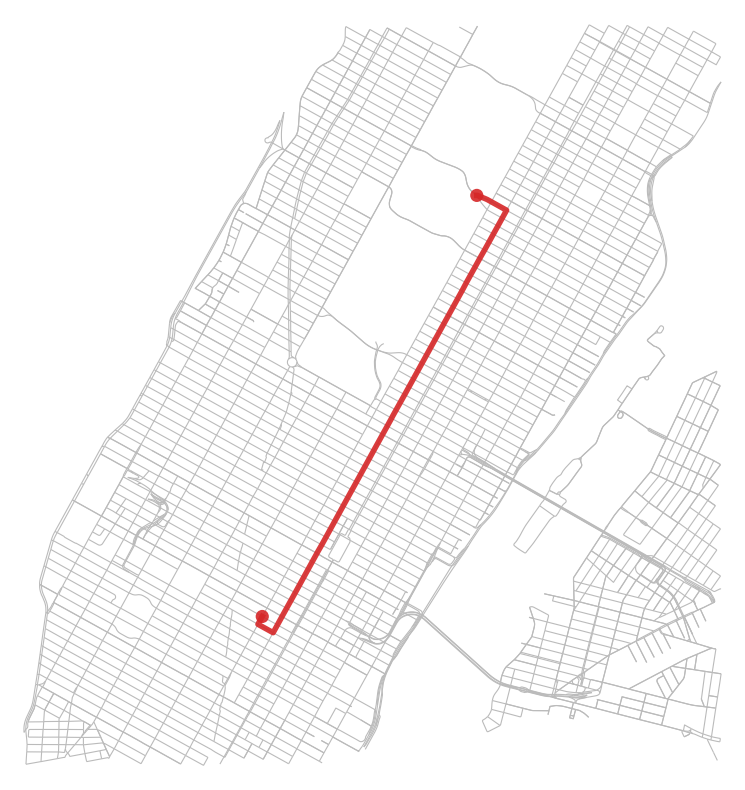

In [5]:
fig, ax = ox.plot.plot_graph_route(
    G,
    route,
    route_color="#D62728",
    route_linewidth=4,
    route_alpha=0.9,
    orig_dest_size=90,
    node_size=0,
    bgcolor="white",
    edge_color="#BBBBBB",
    edge_linewidth=0.8,
    figsize=(10, 10),
)


## Interactive OpenStreetMap visualization with AntPath


In [6]:
import folium
from folium.plugins import AntPath


def route_coordinates(G, route):
    """Convert an OSMnx route to ordered (latitude, longitude) points."""
    coordinates = []

    for u, v in zip(route[:-1], route[1:]):
        edge = min(
            G.get_edge_data(u, v).values(),
            key=lambda attributes: float(attributes.get("length", math.inf)),
        )
        geometry = edge.get("geometry")

        if geometry is None:
            segment = [
                (G.nodes[u]["y"], G.nodes[u]["x"]),
                (G.nodes[v]["y"], G.nodes[v]["x"]),
            ]
        else:
            segment = [(latitude, longitude) for longitude, latitude in geometry.coords]
            u_point = (G.nodes[u]["y"], G.nodes[u]["x"])
            first_distance = (segment[0][0] - u_point[0]) ** 2 + (
                segment[0][1] - u_point[1]
            ) ** 2
            last_distance = (segment[-1][0] - u_point[0]) ** 2 + (
                segment[-1][1] - u_point[1]
            ) ** 2
            if last_distance < first_distance:
                segment.reverse()

        if coordinates and coordinates[-1] == segment[0]:
            coordinates.extend(segment[1:])
        else:
            coordinates.extend(segment)

    return coordinates


animated_route = route_coordinates(G, route)
route_map = folium.Map(
    location=center,
    tiles="OpenStreetMap",
    zoom_start=14,
    control_scale=True,
)

AntPath(
    locations=animated_route,
    color="#D62728",
    pulse_color="#FFFFFF",
    weight=6,
    opacity=0.9,
    delay=700,
    dash_array=[10, 20],
    tooltip=f"A* route: {astar_cost:,.1f} m",
).add_to(route_map)

folium.Marker(
    origin_point,
    tooltip="Origin: Empire State Building",
    popup="Empire State Building",
    icon=folium.Icon(color="green", icon="play"),
).add_to(route_map)

folium.Marker(
    destination_point,
    tooltip="Destination: Central Park",
    popup="Central Park",
    icon=folium.Icon(color="red", icon="flag"),
).add_to(route_map)

route_map.fit_bounds(animated_route)
route_map
